In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [67]:
pd.set_option('display.max_columns', None)

In [68]:
df = pd.read_csv(r'commercial_drone_corridors.csv')

In [69]:
df.shape

(12000, 23)

In [70]:
df.head()

,flight_id,timestamp,corridor_id,drone_type,operator_name,airspace_class,cargo_type,season,weather_condition,flight_status,altitude_m,ground_speed_kmh,flight_distance_km,payload_kg,battery_start_pct,battery_end_pct,wind_speed_kmh,temperature_c,visibility_km,corridor_latitude,corridor_longitude,compliant_flight,risk_level
0,FLT-000001,2024-08-02 09:01:00,COR-047,Multirotor,Flytrex,Class E,Retail Package,Winter,Clear,Completed,283.6,67.7,19.58,1.5,83,70,29.4,27.3,2,33.2399,-89.9390,1,High
1,FLT-000002,2022-07-18 13:14:00,COR-031,Multirotor,Wing (Alphabet),Class E,Mail,Winter,Overcast,Completed,203.0,89.8,16.65,5.0,84,73,8.9,30.6,8,45.9157,-118.0784,1,Critical
2,FLT-000003,2021-10-13 09:43:00,COR-042,Multirotor,Flytrex,Class E,Surveillance,Summer,Light Rain,Completed,50.6,72.7,3.29,1.0,98,66,13.4,25.2,20,41.1039,-110.1258,1,High
3,FLT-000004,2024-01-22 08:37:00,COR-019,Fixed-Wing,Skydio,Class G,Emergency Response,Winter,Clear,Completed,369.8,71.7,37.35,1.5,89,44,16.8,14.2,10,38.1705,-84.0897,1,Critical
4,FLT-000005,2023-05-15 07:01:00,COR-023,Fixed-Wing,Wing (Alphabet),Class E,Emergency Response,Autumn,Clear,Completed,392.7,24.6,4.95,1.0,72,41,10.8,19.4,3,28.4324,-96.0944,1,Low


In [71]:
df.tail()

,flight_id,timestamp,corridor_id,drone_type,operator_name,airspace_class,cargo_type,season,weather_condition,flight_status,altitude_m,ground_speed_kmh,flight_distance_km,payload_kg,battery_start_pct,battery_end_pct,wind_speed_kmh,temperature_c,visibility_km,corridor_latitude,corridor_longitude,compliant_flight,risk_level
11995,FLT-011996,2021-05-30 16:02:00,COR-021,Hybrid VTOL,UPS Flight Forward,Class D,Food Delivery,Autumn,Light Rain,Completed,118.9,86.4,12.35,2.0,93,42,6.1,19.3,10,25.1022,-77.2481,1,Medium
11996,FLT-011997,2022-08-16 10:03:00,COR-043,Multirotor,Skydio,Class G,Retail Package,Spring,Light Rain,Completed,42.6,90.0,0.50,1.0,98,72,5.7,16.3,15,44.2207,-101.0048,1,Critical
11997,FLT-011998,2022-10-06 18:32:00,COR-042,Single-Rotor,Manna Drone Delivery,Class G,Food Delivery,Autumn,Clear,Completed,298.9,43.5,16.13,0.0,96,74,18.1,4.4,20,31.7612,-103.4846,1,Critical
11998,FLT-011999,2023-01-05 19:38:00,COR-021,Multirotor,Matternet,Class B,Food Delivery,Summer,Light Rain,Completed,116.4,93.9,7.08,1.5,76,63,20.3,19.0,15,45.6490,-110.6653,1,High
11999,FLT-012000,2023-07-02 20:56:00,COR-005,Fixed-Wing,DroneUp,Class C,Medical Supplies,Autumn,Fog,Aborted,254.5,104.3,13.60,1.5,71,42,4.1,22.1,10,31.9728,-90.8479,1,Low


In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.isna().sum()

flight_id             0
timestamp             0
corridor_id           0
drone_type            0
operator_name         0
airspace_class        0
cargo_type            0
season                0
weather_condition     0
flight_status         0
altitude_m            0
ground_speed_kmh      0
flight_distance_km    0
payload_kg            0
battery_start_pct     0
battery_end_pct       0
wind_speed_kmh        0
temperature_c         0
visibility_km         0
corridor_latitude     0
corridor_longitude    0
compliant_flight      0
risk_level            0
dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   flight_id           12000 non-null  object 
 1   timestamp           12000 non-null  object 
 2   corridor_id         12000 non-null  object 
 3   drone_type          12000 non-null  object 
 4   operator_name       12000 non-null  object 
 5   airspace_class      12000 non-null  object 
 6   cargo_type          12000 non-null  object 
 7   season              12000 non-null  object 
 8   weather_condition   12000 non-null  object 
 9   flight_status       12000 non-null  object 
 10  altitude_m          12000 non-null  float64
 11  ground_speed_kmh    12000 non-null  float64
 12  flight_distance_km  12000 non-null  float64
 13  payload_kg          12000 non-null  float64
 14  battery_start_pct   12000 non-null  int64  
 15  battery_end_pct     12000 non-null  int64  
 16  wind

In [75]:
df.describe()

,altitude_m,ground_speed_kmh,flight_distance_km,payload_kg,battery_start_pct,battery_end_pct,wind_speed_kmh,temperature_c,visibility_km,corridor_latitude,corridor_longitude,compliant_flight
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,213.355375,64.821400,18.018047,1.665250,84.971167,53.080000,11.871483,18.056400,10.193833,35.912988,-97.169913,0.992917
std,106.215626,20.008136,17.772004,1.092341,8.939733,15.699054,11.516305,9.065368,5.710019,6.341726,14.154494,0.083867
min,30.000000,10.000000,0.500000,0.000000,70.000000,16.000000,0.000000,-15.500000,1.000000,25.000300,-121.997600,0.000000
25%,120.900000,51.100000,5.340000,1.000000,77.000000,42.000000,3.400000,11.800000,5.000000,30.432550,-109.380450,1.000000
50%,214.100000,64.900000,12.545000,1.500000,85.000000,53.000000,8.400000,18.000000,10.000000,35.866150,-97.043550,1.000000
75%,303.400000,78.500000,25.140000,2.500000,93.000000,65.000000,16.400000,24.200000,15.000000,41.378600,-84.907075,1.000000
max,399.900000,139.600000,120.000000,5.000000,100.000000,90.000000,60.000000,49.500000,20.000000,46.993800,-73.003700,1.000000


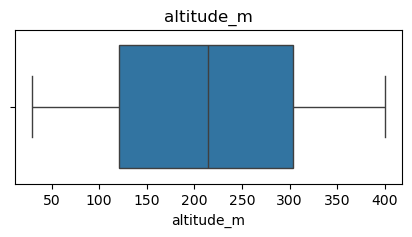

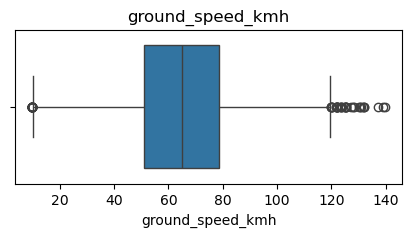

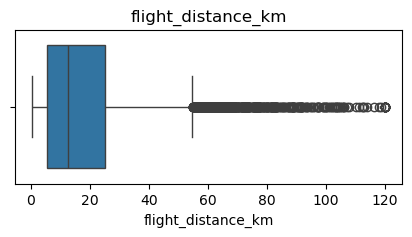

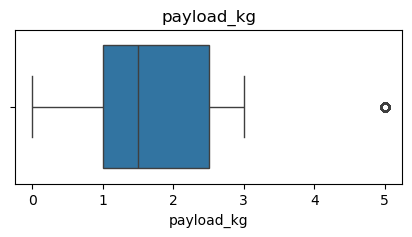

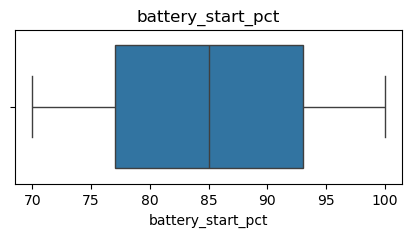

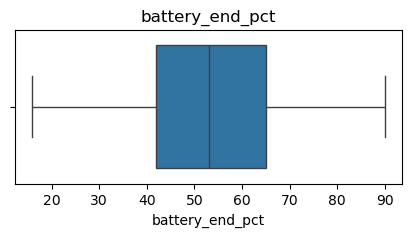

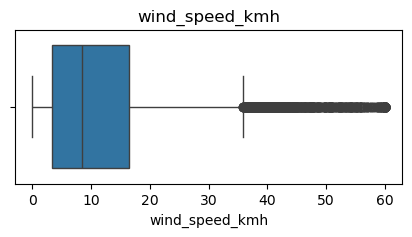

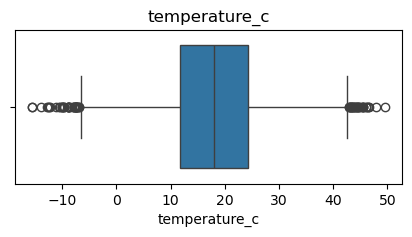

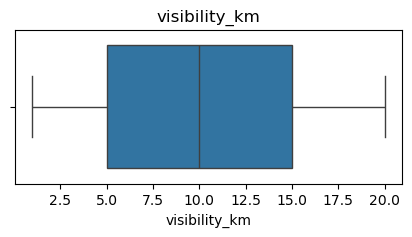

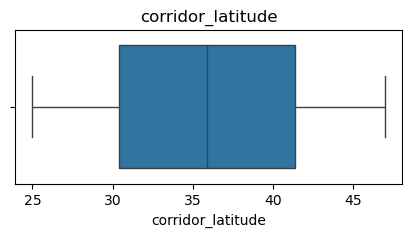

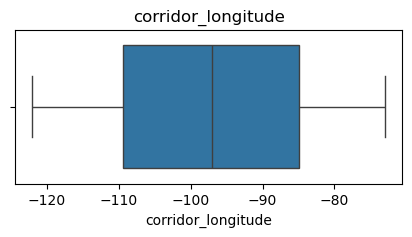

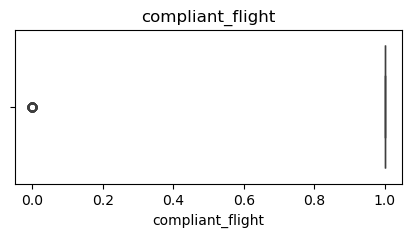

In [76]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# 1-5: UNIVARIATE CATEGORICAL DISTRIBUTIONS

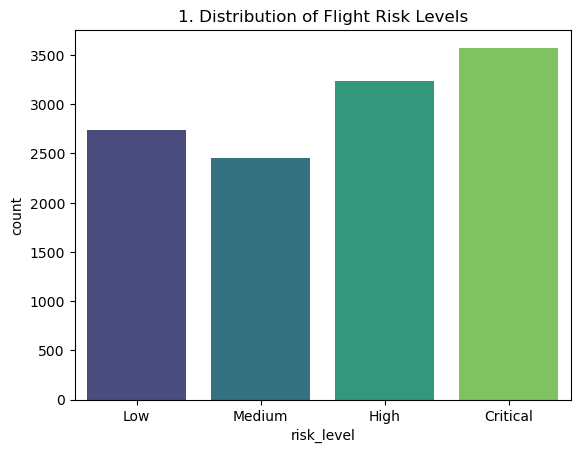

In [77]:
# 1. Target Distribution: Risk Level
plt.figure()
sns.countplot(data=df, x='risk_level', order=['Low', 'Medium', 'High', 'Critical'], palette='viridis')
plt.title('1. Distribution of Flight Risk Levels')
plt.show()

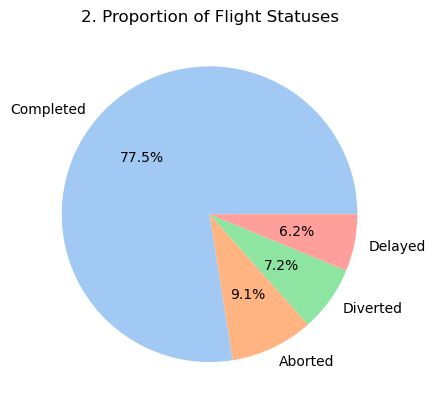

In [78]:
# 2. Flight Status Distribution
plt.figure()
df['flight_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('2. Proportion of Flight Statuses')
plt.ylabel('')
plt.show()

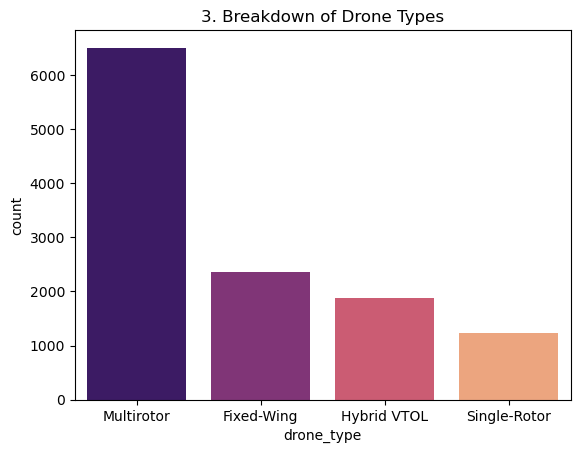

In [79]:
# 3. Drone Type Prevalence
plt.figure()
sns.countplot(data=df, x='drone_type', palette='magma')
plt.title('3. Breakdown of Drone Types')
plt.show()

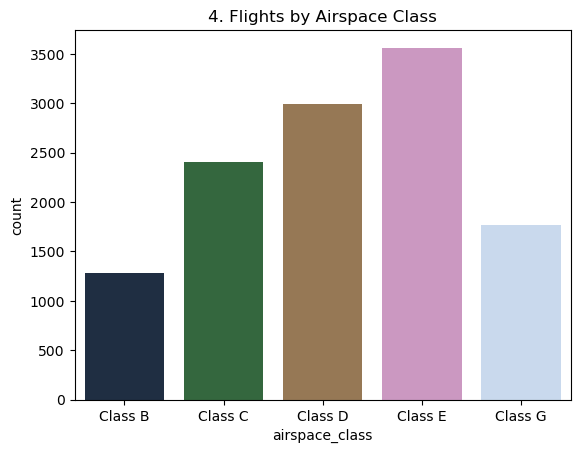

In [80]:
# 4. Airspace Class Distribution
plt.figure()
sns.countplot(data=df, x='airspace_class', order=sorted(df['airspace_class'].unique()), palette='cubehelix')
plt.title('4. Flights by Airspace Class')
plt.show()

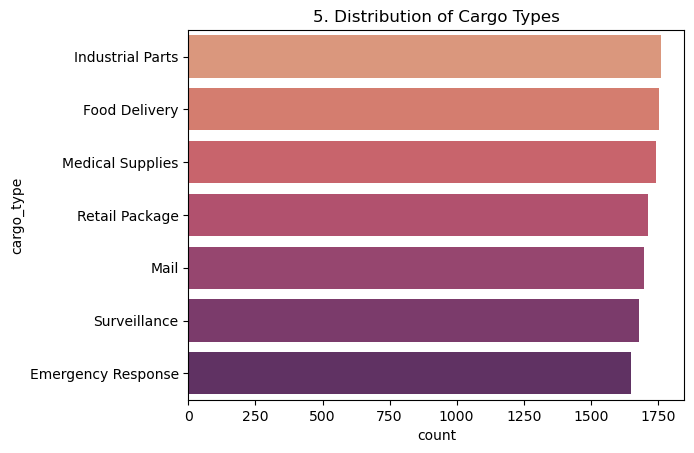

In [81]:
# 5. Cargo Type Variety
plt.figure()
sns.countplot(data=df, y='cargo_type', order=df['cargo_type'].value_counts().index, palette='flare')
plt.title('5. Distribution of Cargo Types')
plt.show()

# 6-10: UNIVARIATE NUMERICAL DISTRIBUTIONS

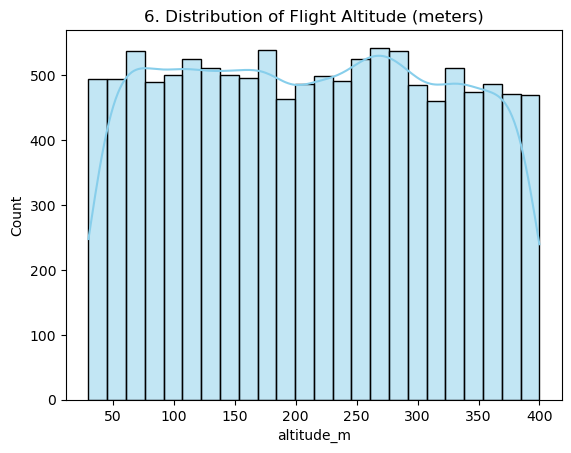

In [82]:
# 6. Altitude Distribution
plt.figure()
sns.histplot(data=df, x='altitude_m', kde=True, color='skyblue')
plt.title('6. Distribution of Flight Altitude (meters)')
plt.show()

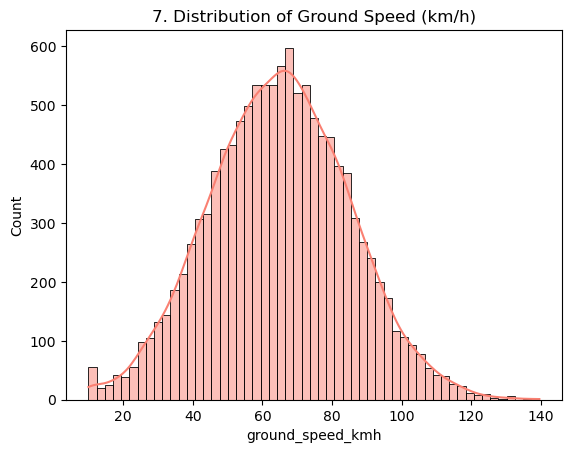

In [83]:
# 7. Ground Speed Distribution
plt.figure()
sns.histplot(data=df, x='ground_speed_kmh', kde=True, color='salmon')
plt.title('7. Distribution of Ground Speed (km/h)')
plt.show()

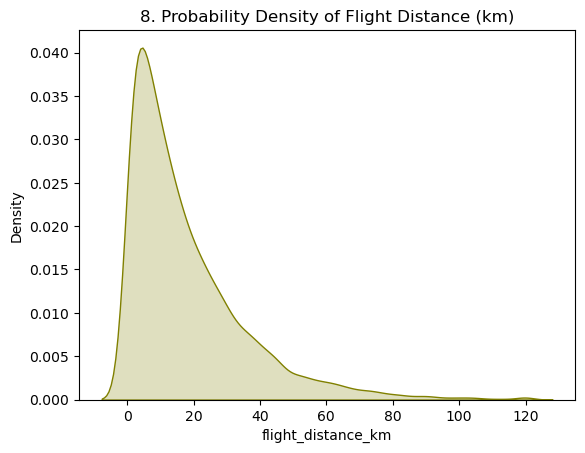

In [84]:
# 8. Flight Distance Analysis
plt.figure()
sns.kdeplot(data=df, x='flight_distance_km', fill=True, color='olive')
plt.title('8. Probability Density of Flight Distance (km)')
plt.show()

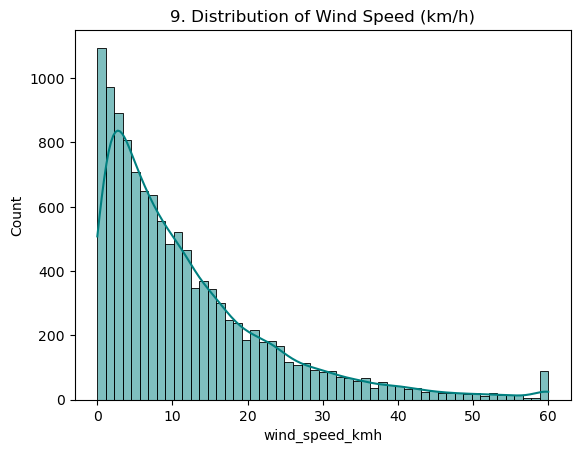

In [85]:
# 9. Wind Speed Profile
plt.figure()
sns.histplot(data=df, x='wind_speed_kmh', kde=True, color='teal')
plt.title('9. Distribution of Wind Speed (km/h)')
plt.show()

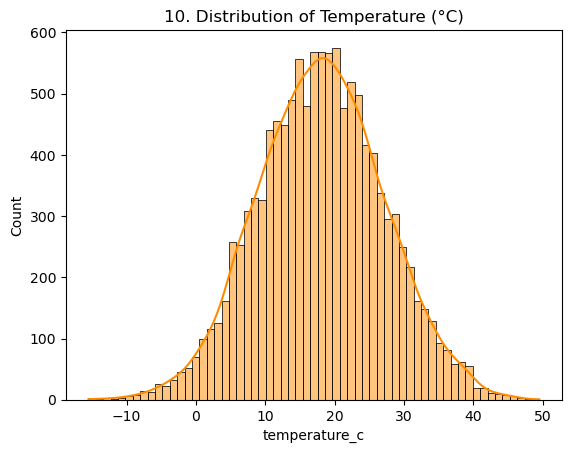

In [86]:
# 10. Ambient Temperature Distribution
plt.figure()
sns.histplot(data=df, x='temperature_c', kde=True, color='darkorange')
plt.title('10. Distribution of Temperature (°C)')
plt.show()

# 11-15: BIVARIATE & MULTIVARIATE RELATIONS

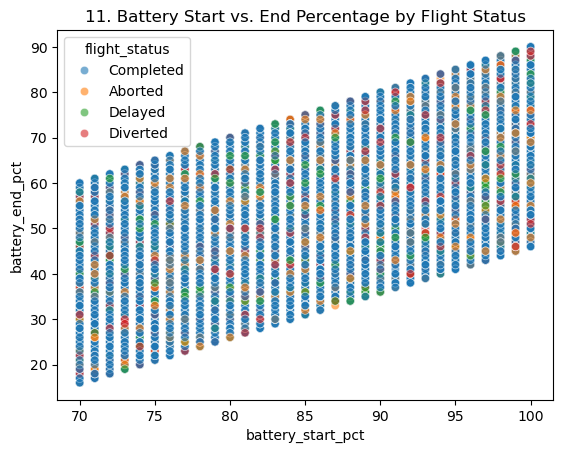

In [87]:
# 11. Battery Consumption Relationship
plt.figure()
sns.scatterplot(data=df, x='battery_start_pct', y='battery_end_pct', hue='flight_status', alpha=0.6)
plt.title('11. Battery Start vs. End Percentage by Flight Status')
plt.show()

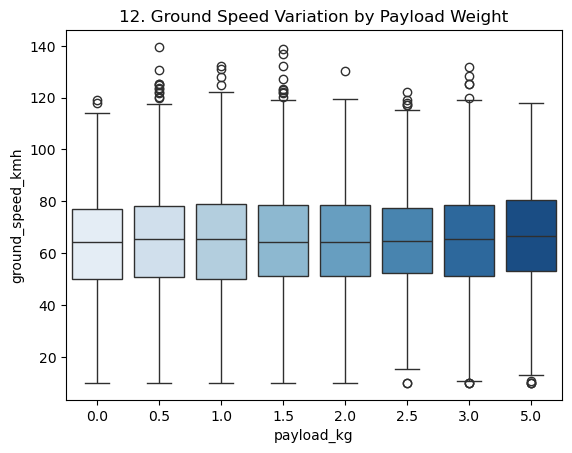

In [88]:
# 12. Payload Weight vs. Ground Speed
plt.figure()
sns.boxplot(data=df, x='payload_kg', y='ground_speed_kmh', palette='Blues')
plt.title('12. Ground Speed Variation by Payload Weight')
plt.show()

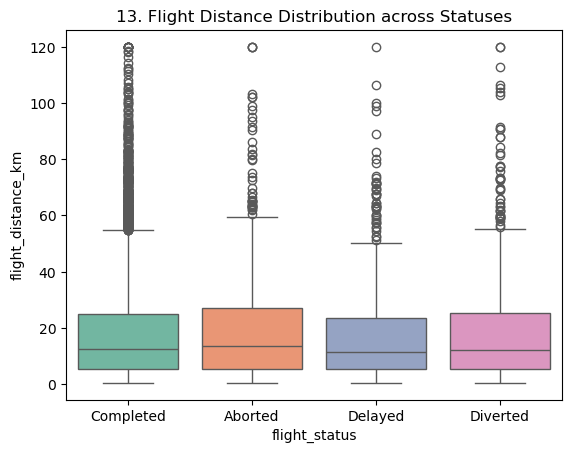

In [89]:
# 13. Boxplot: Distance vs. Flight Status
plt.figure()
sns.boxplot(data=df, x='flight_status', y='flight_distance_km', palette='Set2')
plt.title('13. Flight Distance Distribution across Statuses')
plt.show()

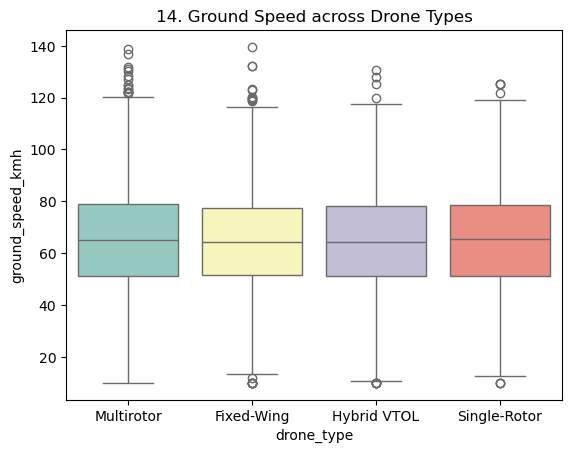

In [90]:
# 14. Boxplot: Speed across Drone Types
plt.figure()
sns.boxplot(data=df, x='drone_type', y='ground_speed_kmh', palette='Set3')
plt.title('14. Ground Speed across Drone Types')
plt.show()

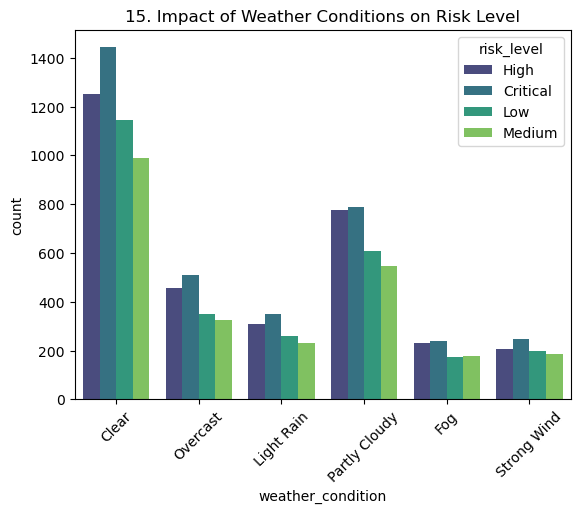

In [91]:
# 15. Risk Level across Weather Conditions
plt.figure()
sns.countplot(data=df, x='weather_condition', hue='risk_level', palette='viridis')
plt.title('15. Impact of Weather Conditions on Risk Level')
plt.xticks(rotation=45)
plt.show()

# ADVANCED FEATURING & MATRIX PLOTS

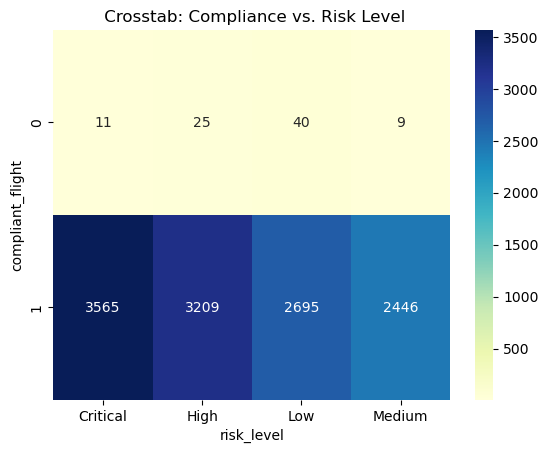

In [92]:
# 16. Compliant Flights vs. Risk Level
plt.figure()
sns.heatmap(pd.crosstab(df['compliant_flight'], df['risk_level']), annot=True, fmt='d', cmap='YlGnBu')
plt.title(' Crosstab: Compliance vs. Risk Level')
plt.show()

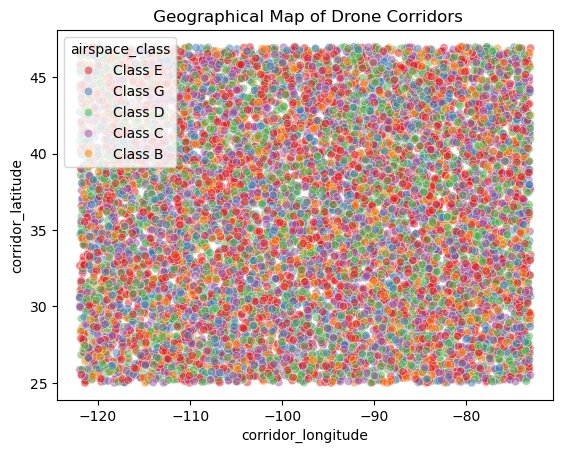

In [93]:
# 17. Geographical Corridor Mapping
plt.figure()
sns.scatterplot(data=df, x='corridor_longitude', y='corridor_latitude', hue='airspace_class', alpha=0.5, palette='Set1')
plt.title(' Geographical Map of Drone Corridors')
plt.show()

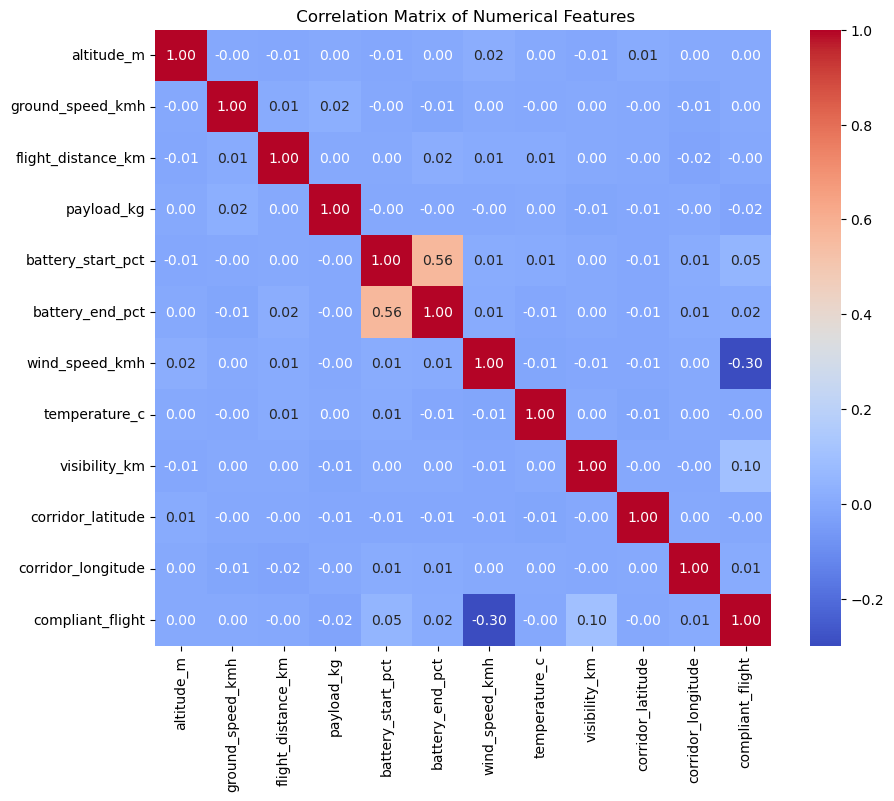

In [94]:
# 18. Numerical Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title(' Correlation Matrix of Numerical Features')
plt.show()

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix

In [96]:
cat_cols = df.select_dtypes('object')

label = LabelEncoder()
for c in cat_cols:
    df[c] = label.fit_transform(df[c])

In [97]:
x = df.drop('risk_level', axis=1)
y = df['risk_level']

In [98]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x_scaler, y, test_size=0.20, random_state=42)

In [100]:
dt = DecisionTreeClassifier()

In [101]:
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [102]:
y_pred = dt.predict(x_test)

In [103]:
print('Accuracy Score : ',accuracy_score(y_test, y_pred)*100)

Accuracy Score :  26.666666666666668


In [104]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.30      0.32       759
           1       0.27      0.27      0.27       635
           2       0.24      0.25      0.25       527
           3       0.20      0.22      0.21       479

    accuracy                           0.27      2400
   macro avg       0.26      0.26      0.26      2400
weighted avg       0.27      0.27      0.27      2400



In [105]:
from sklearn.model_selection import cross_val_score

dt1 = DecisionTreeClassifier()

scores = cross_val_score(dt1, x_train, y_train, cv=5, scoring='accuracy')

print('CV Score: ',scores)
print('Mean CV Accuracy: ',scores.mean(), '+-', scores.std())

CV Score:  [0.26145833 0.253125   0.24166667 0.2703125  0.2546875 ]
Mean CV Accuracy:  0.25625 +- 0.009484316366741703


In [106]:
# Define Hyperparameter Space
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [108]:
# 1. GridSearchCV Implementation

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), 
                           param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
best_grid_model = grid_search.best_estimator_

In [109]:
# 2. RandomizedSearchCV Implementation

random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), 
                                   param_distributions=param_grid, n_iter=10, cv=3, 
                                   scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(x_train, y_train)
best_random_model = random_search.best_estimator_

In [110]:
# RESIDUAL ANALYSIS FOR CLASSIFICATION

def plot_classification_residuals(model, x_test, y_test, title):
    """
    Computes classification probability residuals (y_true_onehot - y_prob)
    and plots their variance distribution.
    """
    # Get predicted probabilities for each class
    y_probs = model.predict_proba(x_test)
    
    # One-hot encode the actual labels
    y_true_onehot = np.eye(len(np.unique(y_test)))[y_test]
    
    # Calculate Residuals (Actual binary indicator - Predicted probability)
    residuals = y_true_onehot - y_probs
    
    # Flatten residuals to get overall system error tendencies
    flattened_residuals = residuals.ravel()
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Residual Distribution Histogram
    sns.histplot(flattened_residuals, kde=True, bins=30, ax=axes[0], color='indigo')
    axes[0].set_title(f'Residuals Distribution ({title})')
    axes[0].set_xlabel('Residual Error (Actual - Predicted Probability)')
    
    # Predicted Probabilities vs Residuals Scatter
    axes[1].scatter(y_probs.ravel(), flattened_residuals, alpha=0.2, color='teal', edgecolors='none')
    axes[1].axhline(y=0, color='red', linestyle='--')
    axes[1].set_title(f'Residuals vs. Predicted Probabilities ({title})')
    axes[1].set_xlabel('Predicted Probabilities')
    axes[1].set_ylabel('Residuals')
    
    plt.suptitle(f'Optimization Residual Analytics Dashboard: {title}', fontsize=14)
    plt.tight_layout()
    plt.show()

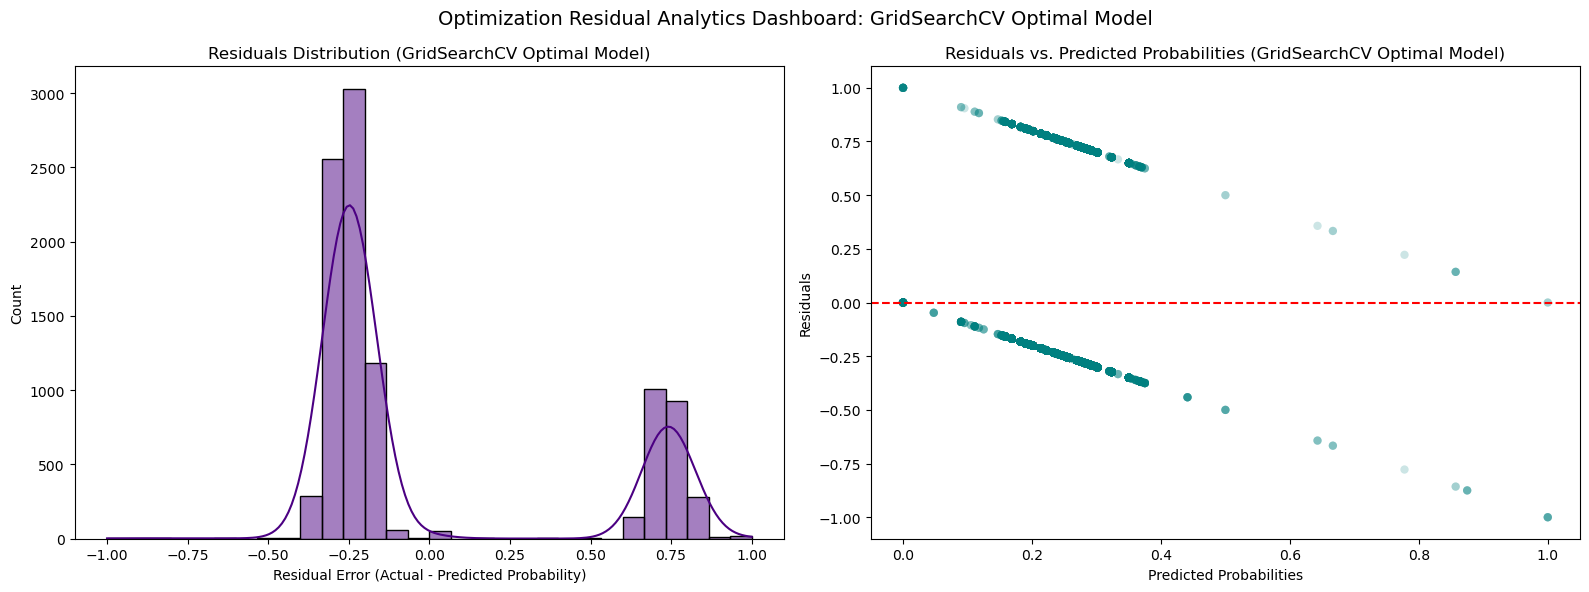

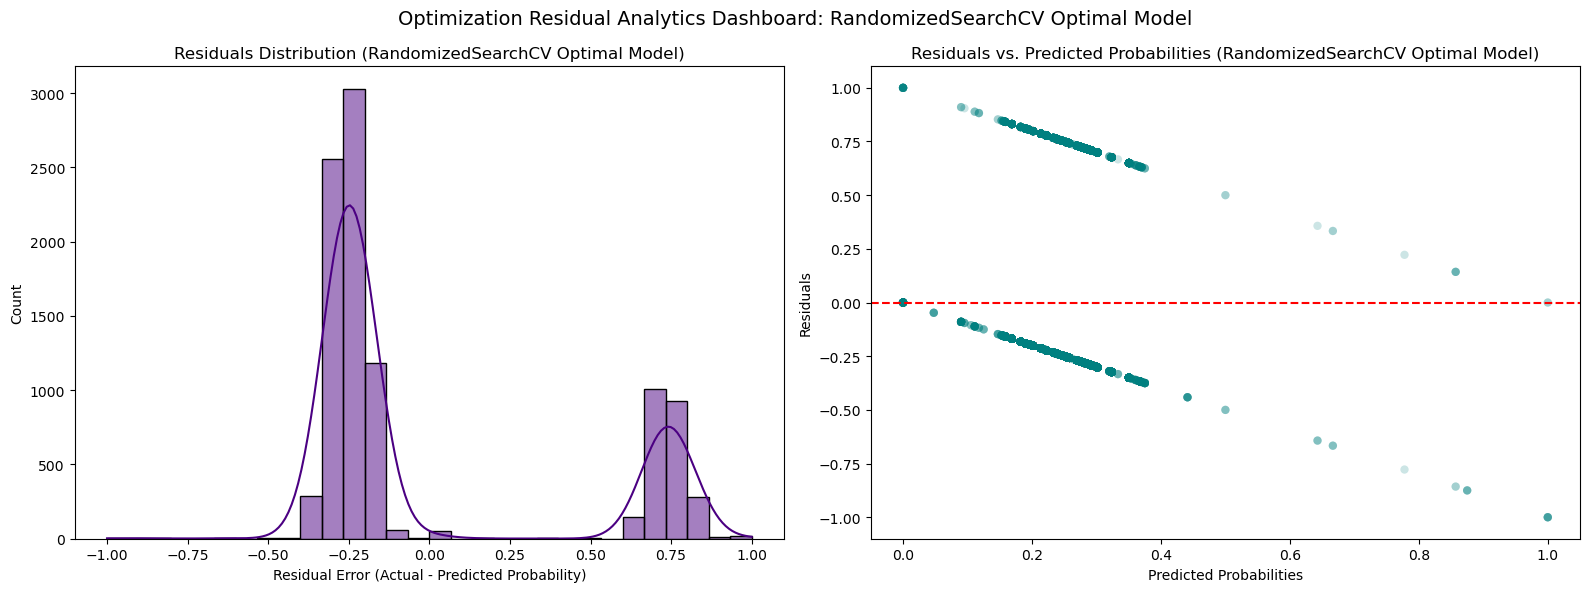

In [112]:
# Generate and display diagnostic charts
plot_classification_residuals(best_grid_model, x_test, y_test, "GridSearchCV Optimal Model")
plot_classification_residuals(best_random_model, x_test, y_test, "RandomizedSearchCV Optimal Model")

In [113]:
# Output operational statistics
print("GridSearchCV Best Parameters Summary:", grid_search.best_params_)
print("RandomizedSearchCV Best Parameters Summary:", random_search.best_params_)

GridSearchCV Best Parameters Summary: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
RandomizedSearchCV Best Parameters Summary: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}


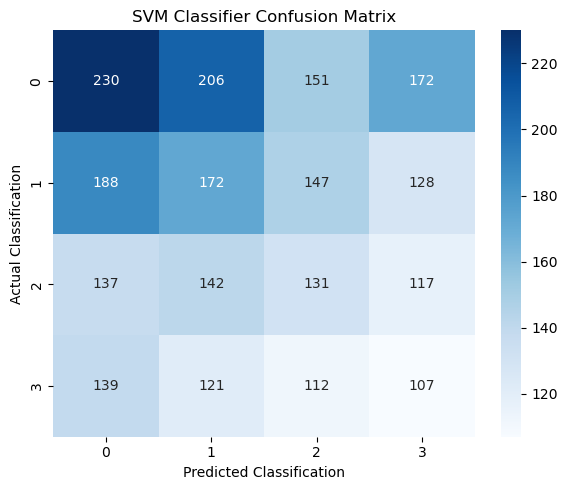

In [114]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1','2','3'], yticklabels=['0', '1','2','3'])
plt.ylabel('Actual Classification')
plt.xlabel('Predicted Classification')
plt.title('SVM Classifier Confusion Matrix')
plt.tight_layout()